# Imports

In [197]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from scipy.stats import levy_stable
import seaborn as sns

# First Steps

In [148]:
ticker = "BTC-USD"

# Récupération des données depuis le début (2010-07-17 = première data Yahoo)
btc = yf.download(
    ticker,
    start="2010-07-17",
    interval="1d",
    auto_adjust=False,
    progress=False
)

In [149]:
btc = btc.dropna()
btc.index = pd.to_datetime(btc.index)

In [150]:
btc.to_csv("bitcoin_full_history.csv")

In [151]:
btc.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2014-09-17,457.334015,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,398.821014,412.425995,393.181000,408.084991,26580100


In [152]:
btc.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2026-02-26,67453.773438,67453.773438,68843.351562,66523.734375,67954.867188,42988597523
2026-02-27,65881.796875,65881.796875,68220.406250,64946.035156,67456.515625,40283655942
2026-02-28,66995.859375,66995.859375,67714.523438,63062.218750,65878.929688,42041497112
2026-03-01,65738.101562,65738.101562,68162.820312,65076.730469,67005.882812,40733141929
2026-03-02,65452.218750,65452.218750,66972.796875,65452.218750,65758.101562,42670804992


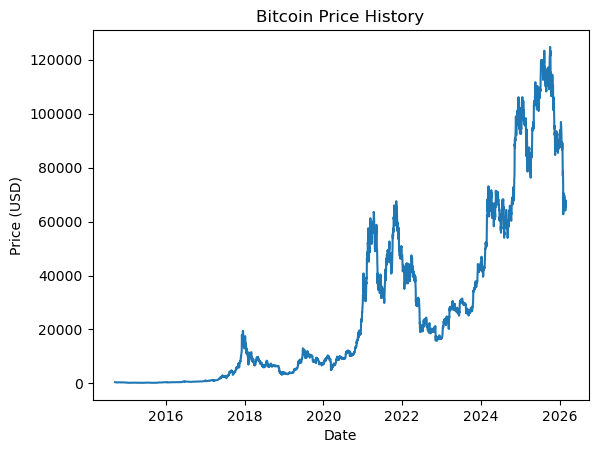

In [153]:
plt.figure()
plt.plot(btc["Close"])
plt.title("Bitcoin Price History")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

In [154]:
btc["log_return"] = (btc["Close"] / btc["Close"].shift(1)).apply(lambda x: np.log(x))
btc["return"] = btc["Close"].pct_change()

<Axes: >

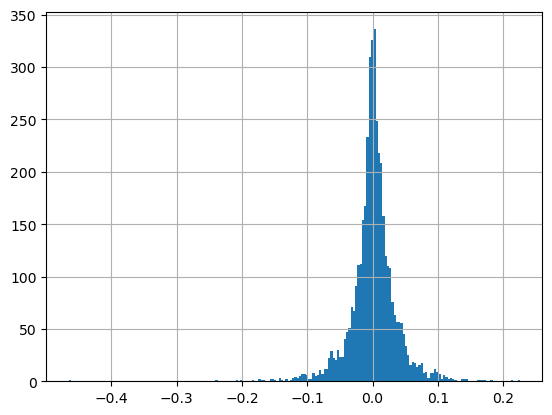

In [155]:
btc['log_return'].hist(bins=200)

In [156]:
r = btc["log_return"].dropna()

print("Mean:", r.mean())
print("Std:", r.std())
print("Skewness:", skew(r))
print("Excess Kurtosis:", kurtosis(r))

Mean: 0.001186343609173173
Std: 0.0353884849062308
Skewness: -0.7105163219417255
Excess Kurtosis: 11.719822550295952


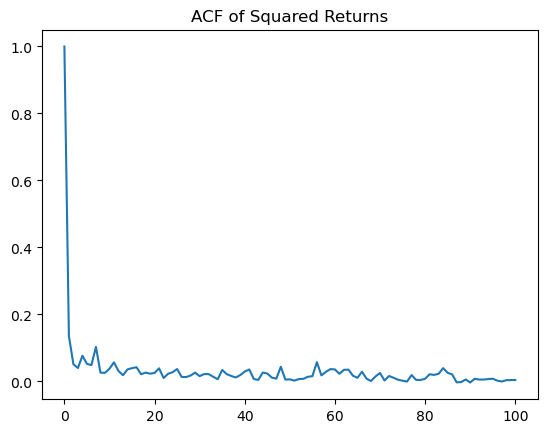

In [157]:
btc["vol_proxy"] = r**2

acf_vol = acf(btc["vol_proxy"].dropna(), nlags=100)

plt.figure()
plt.plot(acf_vol)
plt.title("ACF of Squared Returns")
plt.show()

<Axes: >

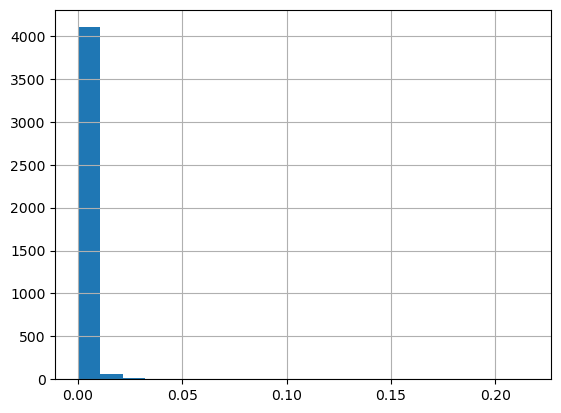

In [158]:
btc["vol_proxy"].hist(bins=20)

<Axes: xlabel='Date'>

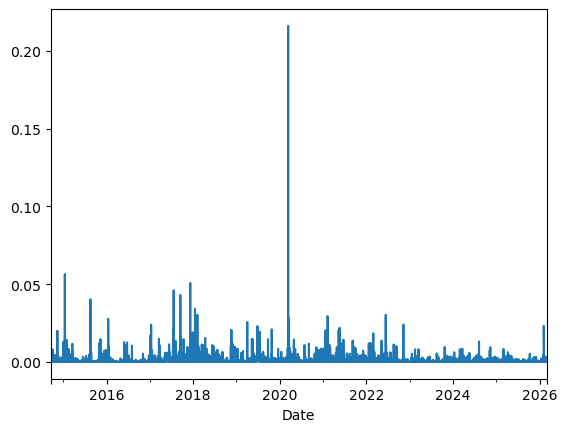

In [159]:
btc["vol_proxy"].plot()

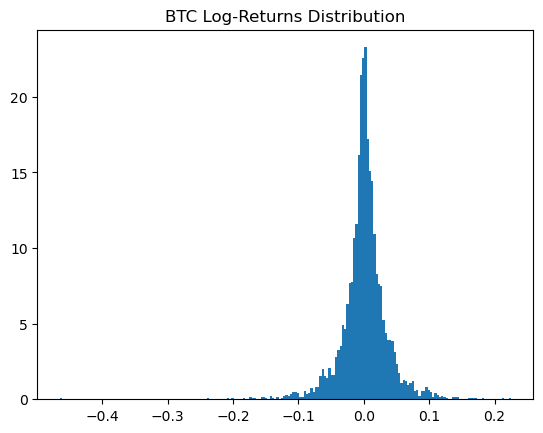

In [160]:
plt.figure()
plt.hist(r, bins=200, density=True)
plt.title("BTC Log-Returns Distribution")
plt.show()

In [161]:
btc['log_return'].describe()

count    4184.000000
mean        0.001186
std         0.035388
min        -0.464730
25%        -0.012663
50%         0.001088
75%         0.015844
max         0.225119
Name: log_return, dtype: float64

In [162]:
btc['return'].describe()

count    4184.000000
mean        0.001809
std         0.035152
min        -0.371695
25%        -0.012583
50%         0.001088
75%         0.015970
max         0.252472
Name: return, dtype: float64

# Heavy Taildness

In [163]:
def hill_estimator(data, k=1000):
    x = np.sort(np.abs(data))
    x = x[-k:]
    x_k = x[0]
    hill = (1/k) * np.sum(np.log(x/x_k))
    return 1/hill

alpha = hill_estimator(r.values, k=1000)
print("Tail index alpha:", alpha)

Tail index alpha: 1.8621115171251745


# Market Efficiency

In [164]:
def robust_acf_test(r, lag=1, q=8):
    T = len(r)
    m = T//q
    
    acfs = []
    
    for i in range(q):
        block = r[i*m:(i+1)*m]
        acf_val = np.corrcoef(block[:-lag], block[lag:])[0,1]
        acfs.append(acf_val)
    
    acfs = np.array(acfs)
    
    t_stat = acfs.mean() / (acfs.std()/np.sqrt(q))
    
    return t_stat

print("Robust ACF t-stat:", robust_acf_test(r.values))

Robust ACF t-stat: -1.9086509503176914


## Volatility Clustering

In [165]:
print("Robust Vol Clustering:",
      robust_acf_test((r**2).values))

Robust Vol Clustering: 4.530599857882388


# First Framework : A Test

In [222]:
halving_dates = pd.to_datetime([
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20"
])

def halving_effect(dates, gamma=0.01, window=800):
    """
    Halving effect with temporary exponential decay.
    
    Parameters
    ----------
    dates : pd.DatetimeIndex
    gamma : float
        Speed of decay (higher = faster decay)
    window : int
        Maximum number of days during which the halving has an effect
    
    Returns
    -------
    H : np.array
        Time-varying halving effect
    """
    
    H = np.zeros(len(dates))
    
    for tau in halving_dates:
        
        dt = (dates - tau).days
        
        contrib = np.where(
            (dt > 0) & (dt < window),
            np.exp(-gamma * dt),
            0
        )
        
        H += contrib
    
    return H

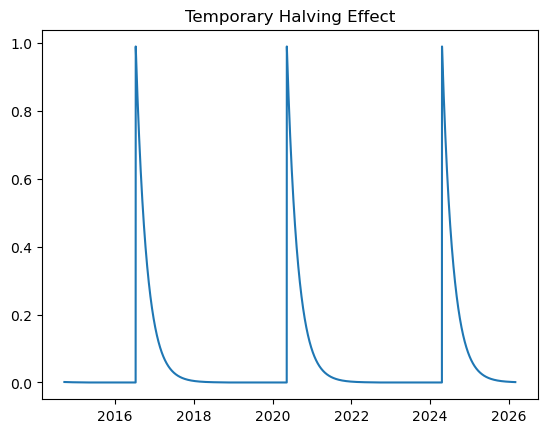

In [223]:
btc["H_temp"] = halving_effect(btc.index)

plt.plot(btc.index, btc["H_temp"])
plt.title("Temporary Halving Effect")
plt.show()

In [224]:
def stable_noise(alpha, size, dt):
    return levy_stable.rvs(alpha,
                           0,
                           scale=dt**(1/alpha),
                           size=size)

In [225]:
def simulate_crypto_model(
    T=6000,
    dt=1/365,
    S0=1,
    v0=0.04,
    alpha=1.86,
    mu0=0.02,
    beta=0.05,
    kappa=2,
    theta0=0.04,
    eta=0.03,
    xi=0.5,
    gamma=0.002
):
    
    dates = pd.date_range("2010-07-17", periods=T)
    
    H = halving_effect(dates, gamma)
    
    S = np.zeros(T)
    v = np.zeros(T)
    
    S[0] = S0
    v[0] = v0
    
    for t in range(1, T):
        
        dL = stable_noise(alpha,1,dt)
        dB = np.sqrt(dt)*np.random.randn()
        
        theta_t = theta0 + eta*H[t]
        
        v[t] = (
            v[t-1]
            + kappa*(theta_t - v[t-1])*dt
            + xi*np.sqrt(v[t-1])*dB
        )
        
        v[t] = np.maximum(v[t],1e-8)
        
        mu_t = mu0 + beta*H[t]
        
        S[t] = (
            S[t-1]
            * np.exp(
                mu_t*dt
                + np.sqrt(v[t-1])*dL
            )
        )
        
    return dates,S,v

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_4608/1944644040.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S[t] = (


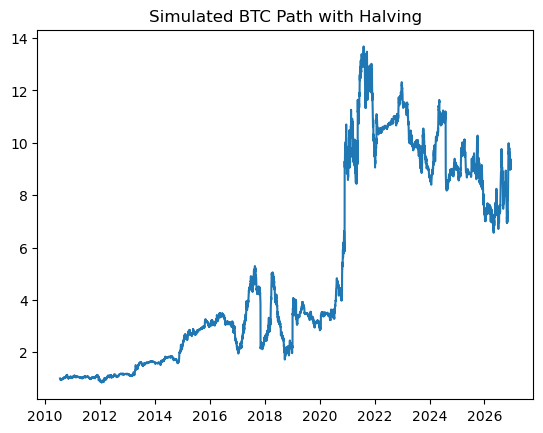

In [226]:
dates,S,v = simulate_crypto_model()

plt.figure()
plt.plot(dates,S)
plt.title("Simulated BTC Path with Halving")
plt.show()

In [227]:
r_sim = np.diff(np.log(S))

from scipy.stats import kurtosis

print("Simulated Kurtosis:",
      kurtosis(r_sim))

Simulated Kurtosis: 220.9236432731599


In [228]:
print("Simulated alpha:",
      hill_estimator(r_sim))

Simulated alpha: 2.04967324233507


In [229]:
print("Simulated clustering:",
      robust_acf_test(r_sim**2))

Simulated clustering: 1.5232464484228065


# Beta Calibration

In [211]:
halving_dates = pd.to_datetime([
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20"
])

btc["H"] = 0

gamma = 0.002

for tau in halving_dates:
    
    dt = (btc.index - tau).days
    
    contrib = np.where(dt > 0,
                       1 - np.exp(-gamma*dt),
                       0)
    
    btc["H"] += contrib

In [212]:
import statsmodels.api as sm

df = btc.dropna()

X = sm.add_constant(df["H"])
y = df["log_return"]

model = sm.QuantReg(y, X)

res = model.fit(q=0.5)

print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:             log_return   Pseudo R-squared:            0.0008217
Model:                       QuantReg   Bandwidth:                    0.006474
Method:                 Least Squares   Sparsity:                      0.04507
Date:                Mon, 02 Mar 2026   No. Observations:                 4184
Time:                        15:25:36   Df Residuals:                     4182
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.001      3.287      0.001       0.001       0.005
H             -0.0009      0.000     -2.248      0.025      -0.002      -0.000


In [213]:
beta_hat = res.params["H"]

beta_model = beta_hat * 365

In [214]:
beta_model

np.float64(-0.3274441863513284)

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_4608/1944644040.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S[t] = (


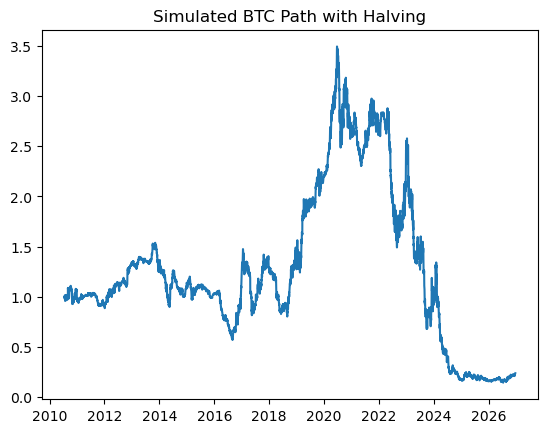

In [215]:
dates, S, v = simulate_crypto_model(
    beta=beta_model
)

plt.figure()
plt.plot(dates,S)
plt.title("Simulated BTC Path with Halving")
plt.show()

# Correlation Data Analysis

In [216]:
tickers = {
    "BTC": "BTC-USD",
    "GOLD": "GC=F",
    "SP500": "^GSPC",
    "NASDAQ": "^IXIC"
}

data = yf.download(
    list(tickers.values()),
    start="2010-07-17",
    interval="1d",
    progress=False
)["Close"]

data.columns = tickers.keys()

data = data.dropna()

/var/folders/nk/kpj6413n2lj1cln9c1z0_pj80000gn/T/ipykernel_4608/3634030389.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


In [217]:
returns = np.log(data/data.shift(1)).dropna()

In [218]:
window = 90

corr_btc_gold = returns["BTC"].rolling(window).corr(returns["GOLD"])
corr_btc_sp = returns["BTC"].rolling(window).corr(returns["SP500"])
corr_btc_nasdaq = returns["BTC"].rolling(window).corr(returns["NASDAQ"])

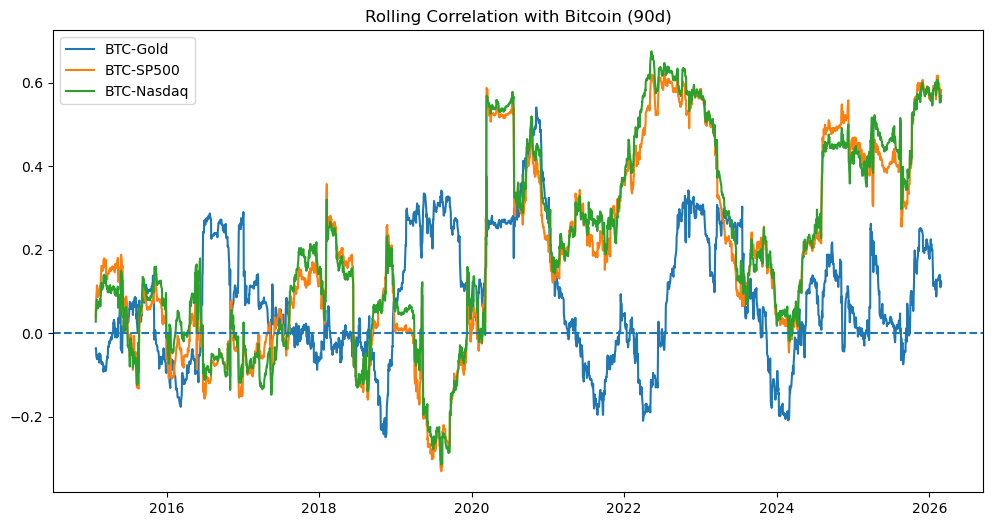

In [219]:
plt.figure(figsize=(12,6))

plt.plot(corr_btc_gold, label="BTC-Gold")
plt.plot(corr_btc_sp, label="BTC-SP500")
plt.plot(corr_btc_nasdaq, label="BTC-Nasdaq")

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Rolling Correlation with Bitcoin (90d)")
plt.show()

In [220]:
returns["year"] = returns.index.year

print(returns.groupby("year").corr()["BTC"])

year        
2014  BTC       1.000000
      GOLD     -0.058700
      SP500    -0.090978
      NASDAQ   -0.035095
2015  BTC       1.000000
      GOLD     -0.010416
      SP500     0.061106
      NASDAQ    0.053839
2016  BTC       1.000000
      GOLD      0.102321
      SP500    -0.032306
      NASDAQ    0.000931
2017  BTC       1.000000
      GOLD     -0.014102
      SP500     0.067108
      NASDAQ    0.075340
2018  BTC       1.000000
      GOLD      0.011733
      SP500     0.081435
      NASDAQ    0.079425
2019  BTC       1.000000
      GOLD      0.215690
      SP500    -0.109387
      NASDAQ   -0.097220
2020  BTC       1.000000
      GOLD      0.280976
      SP500     0.446654
      NASDAQ    0.462648
2021  BTC       1.000000
      GOLD     -0.054967
      SP500     0.263868
      NASDAQ    0.273203
2022  BTC       1.000000
      GOLD      0.101961
      SP500     0.563573
      NASDAQ    0.594138
2023  BTC       1.000000
      GOLD      0.106351
      SP500     0.157335
      NASDAQ

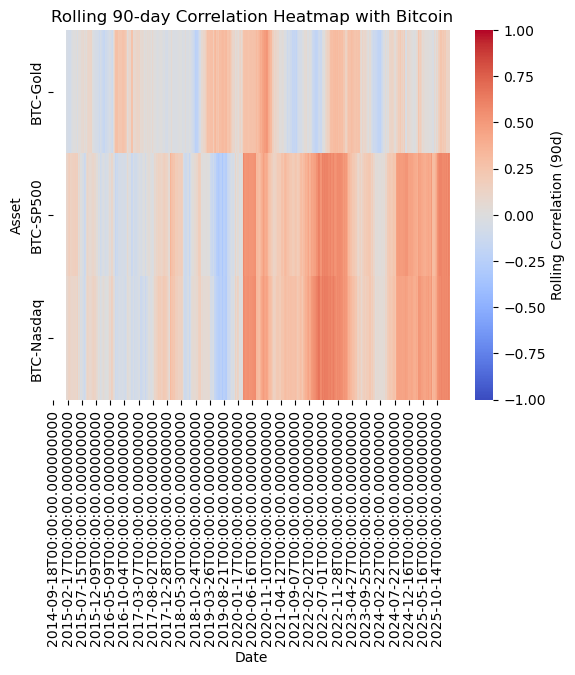

In [221]:
rolling_corrs = pd.DataFrame({
    "BTC-Gold": returns["BTC"].rolling(window).corr(returns["GOLD"]),
    "BTC-SP500": returns["BTC"].rolling(window).corr(returns["SP500"]),
    "BTC-Nasdaq": returns["BTC"].rolling(window).corr(returns["NASDAQ"])
}, index=returns.index)

sns.heatmap(
    rolling_corrs.T,  # transpose pour que les actifs soient sur l'axe y
    cmap="coolwarm",
    vmin=-1, vmax=1,
    cbar_kws={"label": "Rolling Correlation (90d)"}
)

plt.title("Rolling 90-day Correlation Heatmap with Bitcoin")
plt.xlabel("Date")
plt.ylabel("Asset")
plt.show()

# Seconde modélisation : Fondamentale

In [300]:
# ----------------------
# Paramètres de simulation
# ----------------------
total_supply = 21_000_000
initial_reward = 50          # BTC/block
halving_blocks = 210_000
block_time = 10/60/24        # jours par block (~10 min)
T_days = 5000                # durée simulation (~13 ans)
dt = 1                       # pas journalier

# Adoption & demande
D0 = 10000                     # demande initiale arbitraire
phi = 0.0005                 # croissance adoption journalière
alpha_noise = 1.86            # heavy tail alpha

# Coût minage (floor)
C_floor = 5000               # prix plancher pour rentabilité

# k = facteur de rareté / conversion
k = 1e5

In [301]:
# ----------------------
# Générer l’offre cumulative
# ----------------------
def compute_supply(T_days, initial_reward=50, halving_blocks=210000, block_time=10/60/24):
    B_t = np.arange(1, T_days+1) / block_time
    supply = np.zeros_like(B_t)
    for t, B in enumerate(B_t):
        halving_n = int(B // halving_blocks)
        reward = initial_reward / 2**halving_n
        blocks_in_current_halving = B - halving_n * halving_blocks
        supply[t] = np.sum([halving_blocks * (initial_reward / 2**i) for i in range(halving_n)]) \
                    + blocks_in_current_halving * reward
    supply = np.minimum(supply, total_supply)
    return supply

In [302]:
# ----------------------
# Générer la demande stochastique
# ----------------------
def simulate_demand(T_days, D0=1e6, phi=0.0005, alpha=1.86):
    D = np.zeros(T_days)
    D[0] = D0
    for t in range(1, T_days):
        growth = D[t-1]*phi
        shock = levy_stable.rvs(alpha, 0, scale=1e4)
        D[t] = max(D[t-1] + growth + shock, 0)
    return D

In [303]:
# ----------------------
# Prix comme équilibre offre/demande + plancher minage
# ----------------------
def compute_price(S_t, D_t, k=1e6, C_floor=5000):
    P_t = k * D_t / np.maximum(total_supply - S_t, 1e-8)
    P_t = np.maximum(P_t, C_floor)
    return P_t

In [304]:
# ----------------------
# Simulation complète
# ----------------------
supply = compute_supply(T_days)
demand = simulate_demand(T_days, D0, phi, alpha_noise)
price = compute_price(supply, demand, k, C_floor)

dates = pd.date_range(start="2010-07-17", periods=T_days)

df = pd.DataFrame({
    "Supply": supply,
    "Demand": demand,
    "Price": price
}, index=dates)

alpha_noise = 1.86
sigma_noise = 0.03  # ajustable pour volatilité journalière ~3%
price_stoch = np.zeros_like(price)
price_stoch[0] = 1000  # prix initial réaliste en 2010

for t in range(1, len(price)):
    drift = (price[t] - price[t-1]) / price[t-1]
    shock = sigma_noise * levy_stable.rvs(alpha_noise, 0)
    price_stoch[t] = price_stoch[t-1] * np.exp(drift + shock)

# Ajouter au DataFrame pour visualisation
df["Price_Stoch"] = price_stoch

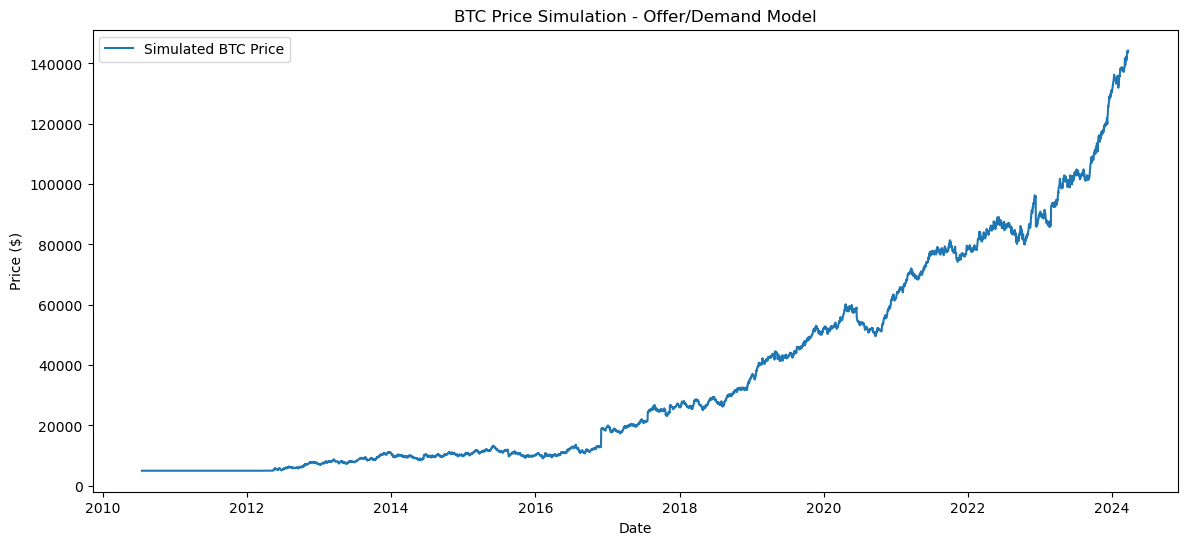

In [305]:
# ----------------------
# Visualisation
# ----------------------
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Price"], label="Simulated BTC Price")
plt.title("BTC Price Simulation - Offer/Demand Model")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.legend()
plt.show()

In [306]:
df["log_return"] = np.log(df["Price"]/df["Price"].shift(1))
returns = df["log_return"].dropna()

# Skew, Kurtosis
from scipy.stats import skew, kurtosis

print("Skew:", skew(returns))
print("Kurtosis:", kurtosis(returns))

# Approximation tail index via Hill estimator
def hill_estimator(x, k=500):
    x = np.sort(np.abs(x))[-k:]
    return 1/np.mean(np.log(x/np.min(x)))

alpha_est = hill_estimator(returns.values, k=500)
print("Estimated alpha (tail index):", alpha_est)

Skew: 5.549672212351023
Kurtosis: 169.12178868019924
Estimated alpha (tail index): 2.681825419119148


Si on définit le drift comme cette équation et qu'on intègre vol heston (CIR model) alors on a quelque chose de probant à mon avis